# 1. Import Modeling Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install optuna

In [28]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.model_selection import learning_curve, StratifiedKFold, cross_validate

import optuna

import joblib

In [8]:
# X_train = pd.read_csv('../Datasets/Modeling/X_train.csv')
# X_val = pd.read_csv('../Datasets/Modeling/X_val.csv')
# X_test = pd.read_csv('../Datasets/Modeling/X_test.csv')

# y_train = pd.read_csv('../Datasets/Modeling/y_train.csv')
# y_val = pd.read_csv('../Datasets/Modeling/y_val.csv')
# y_test = pd.read_csv('../Datasets/Modeling/y_test.csv')

X_train = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/X_train.csv')
X_val = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/X_val.csv')
X_test = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/X_test.csv')

y_train = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/y_train.csv')
y_val = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/y_val.csv')
y_test = pd.read_csv('/content/drive/MyDrive/churn/Datasets/Modeling/y_test.csv')

# 2. Data Preview

In [5]:
X_samples = [X_train, X_val, X_test]
y_samples = [y_train, y_val, y_test]

for X in X_samples:
    display(X.info())

for y in y_samples:
    display(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   int64  
 1   Age                                4930 non-null   int64  
 2   Under 30                           4930 non-null   int64  
 3   Senior Citizen                     4930 non-null   int64  
 4   Married                            4930 non-null   int64  
 5   Number of Dependents               4930 non-null   int64  
 6   City                               4930 non-null   float64
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   int64  
 11  Tenure in Months                   4930 non-null   int64

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             1056 non-null   int64  
 1   Age                                1056 non-null   int64  
 2   Under 30                           1056 non-null   int64  
 3   Senior Citizen                     1056 non-null   int64  
 4   Married                            1056 non-null   int64  
 5   Number of Dependents               1056 non-null   int64  
 6   City                               1056 non-null   float64
 7   Zip Code                           1056 non-null   int64  
 8   Latitude                           1056 non-null   float64
 9   Longitude                          1056 non-null   float64
 10  Number of Referrals                1056 non-null   int64  
 11  Tenure in Months                   1056 non-null   int64

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             1057 non-null   int64  
 1   Age                                1057 non-null   int64  
 2   Under 30                           1057 non-null   int64  
 3   Senior Citizen                     1057 non-null   int64  
 4   Married                            1057 non-null   int64  
 5   Number of Dependents               1057 non-null   int64  
 6   City                               1057 non-null   float64
 7   Zip Code                           1057 non-null   int64  
 8   Latitude                           1057 non-null   float64
 9   Longitude                          1057 non-null   float64
 10  Number of Referrals                1057 non-null   int64  
 11  Tenure in Months                   1057 non-null   int64

...

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Churn Label  1056 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Churn Label  1057 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB


None

# 3. Training Baseline Model

In [9]:
lr = LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42, verbose=0)
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
lgb = LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
xgb = XGBClassifier(scale_pos_weight=float(np.sum(y_train.values == 0)) / np.sum(y_train.values == 1), n_jobs=-1, device='cuda', random_state=42, verbosity=0)
cb = CatBoostClassifier(auto_class_weights='Balanced', thread_count=-1, task_type='GPU', random_state=42, verbose=False)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Lightgbm': lgb,
    'XGBoost': xgb,
    'CatBoost': cb
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)

    cv_results.append({
        'Model': name,
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision']),
        'Recall': np.mean(scores['test_recall']),
        'F1': np.mean(scores['test_f1']),
        'AUC': np.mean(scores['test_roc_auc'])
    })

pd.DataFrame(cv_results).sort_values(by='F1', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,AUC
0,CatBoost,0.834686,0.656442,0.793578,0.718235,0.909120
1,Lightgbm,0.841382,0.681571,0.756881,0.717065,0.903605
2,XGBoost,0.838746,0.690498,0.712538,0.701241,0.897101
3,Random Forest,0.839555,0.758249,0.581804,0.657971,0.892991
4,Logistic Regression,0.722311,0.484517,0.738532,0.585056,0.802906


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       776
           1       0.48      0.75      0.58       281

    accuracy                           0.72      1057
   macro avg       0.68      0.73      0.68      1057
weighted avg       0.78      0.72      0.73      1057



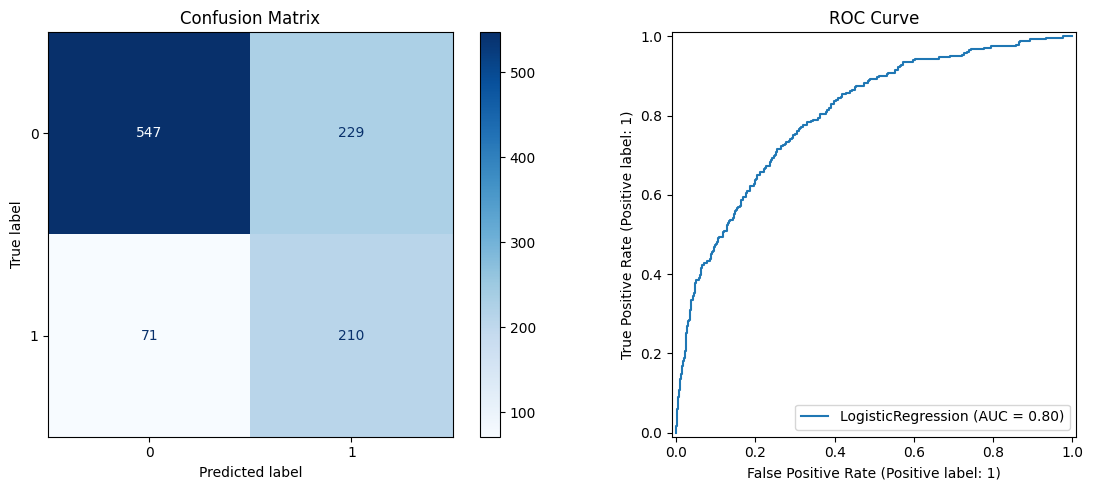

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       776
           1       0.81      0.61      0.70       281

    accuracy                           0.86      1057
   macro avg       0.84      0.78      0.80      1057
weighted avg       0.86      0.86      0.85      1057



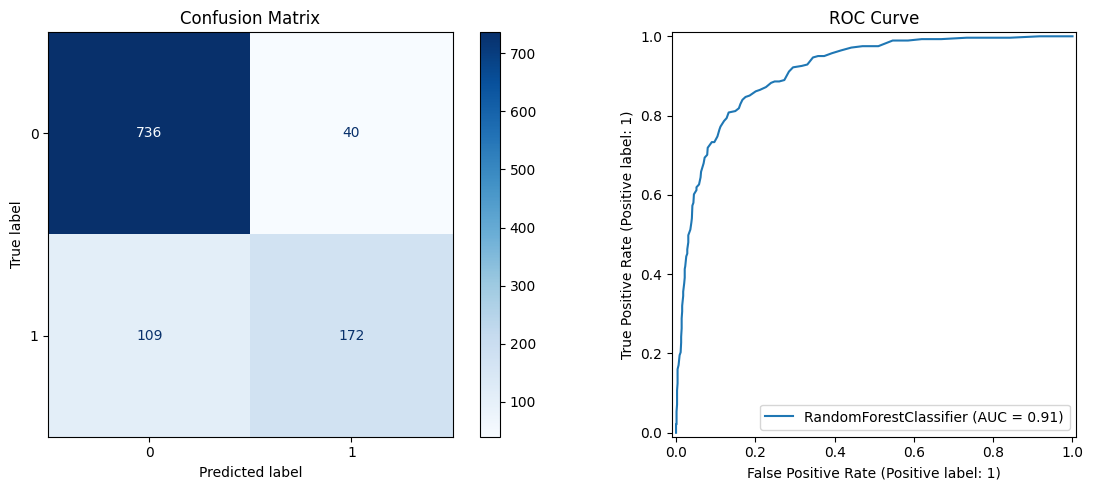

--- Lightgbm Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       776
           1       0.71      0.79      0.75       281

    accuracy                           0.86      1057
   macro avg       0.81      0.83      0.82      1057
weighted avg       0.86      0.86      0.86      1057



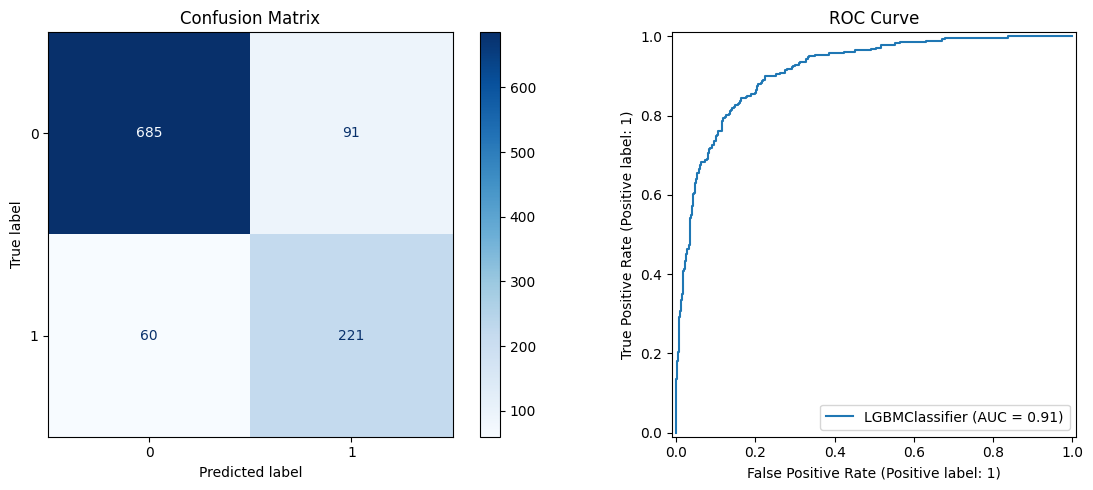

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       776
           1       0.73      0.70      0.72       281

    accuracy                           0.85      1057
   macro avg       0.81      0.80      0.81      1057
weighted avg       0.85      0.85      0.85      1057



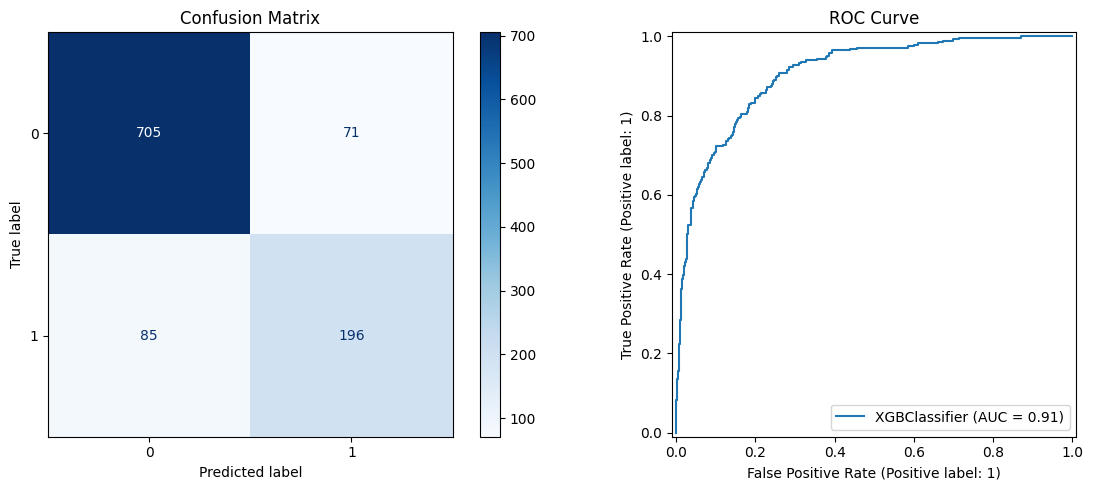

--- CatBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       776
           1       0.68      0.82      0.74       281

    accuracy                           0.85      1057
   macro avg       0.80      0.84      0.82      1057
weighted avg       0.86      0.85      0.85      1057



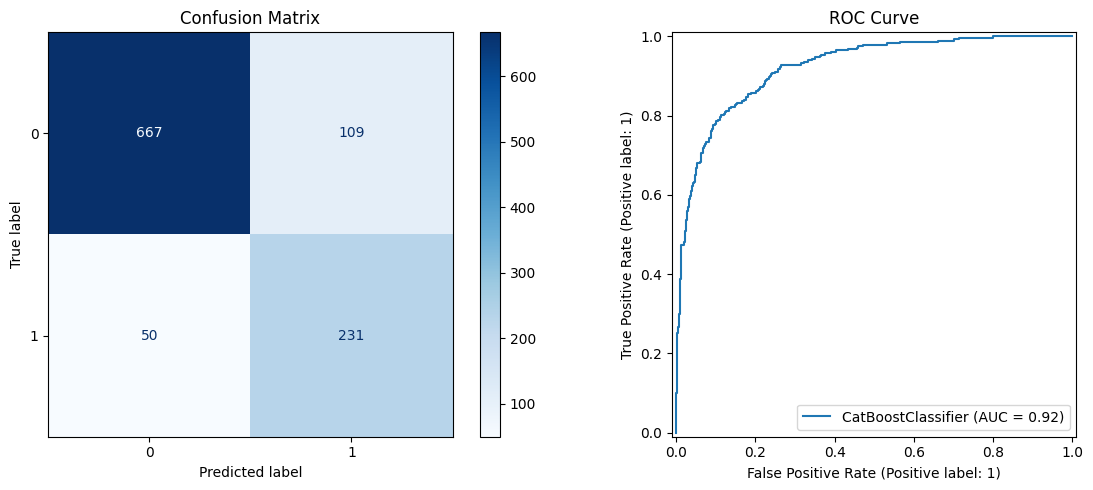

In [10]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    axes[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

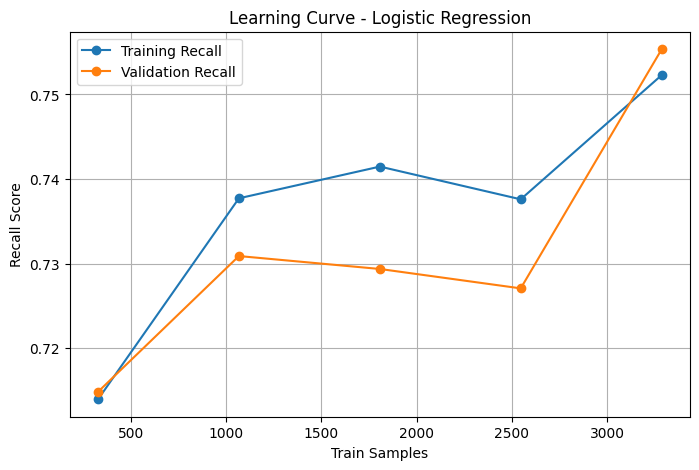

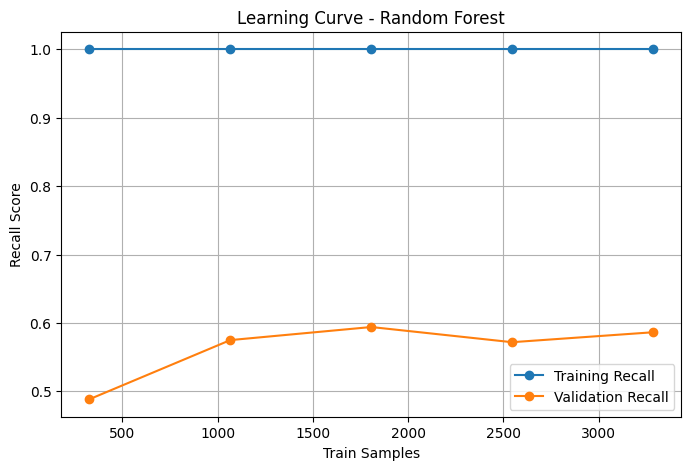

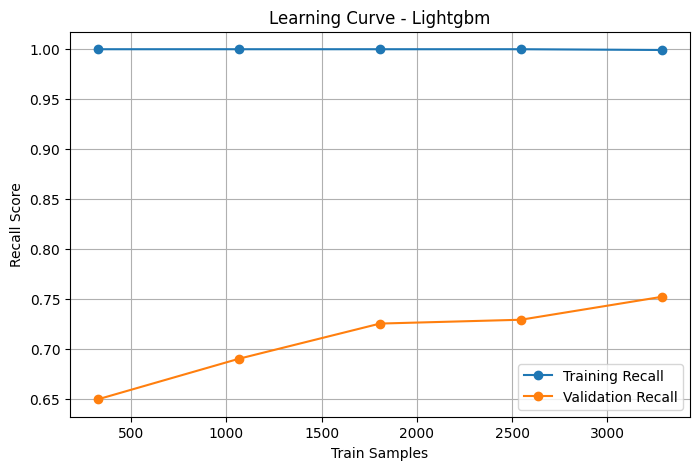

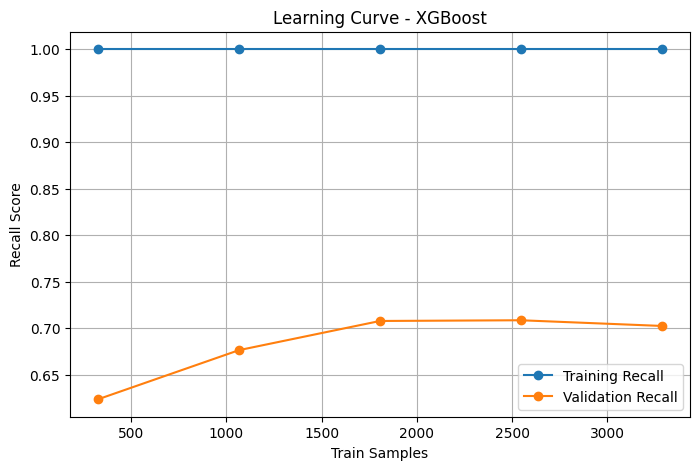

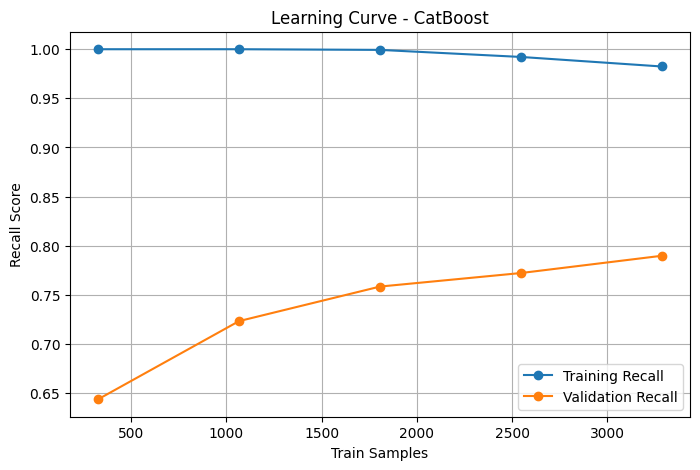

In [11]:
lr = LogisticRegression(class_weight='balanced', n_jobs=-1, random_state=42, verbose=0)
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
lgb = LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
xgb = XGBClassifier(scale_pos_weight=float(np.sum(y_train.values == 0)) / np.sum(y_train.values == 1), n_jobs=-1, device='cuda', random_state=42, verbosity=0)
cb = CatBoostClassifier(auto_class_weights='Balanced', thread_count=-1, task_type='GPU', random_state=42, verbose=False)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Lightgbm': lgb,
    'XGBoost': xgb,
    'CatBoost': cb
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    plt.figure(figsize=(8, 5))

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=cv, scoring='recall'
    )

    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Recall')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation Recall')
    plt.legend()
    plt.xlabel('Train Samples')
    plt.ylabel('Recall Score')
    plt.title(f'Learning Curve - {name}')
    plt.grid()
    plt.show()

# 4. Feature Selection

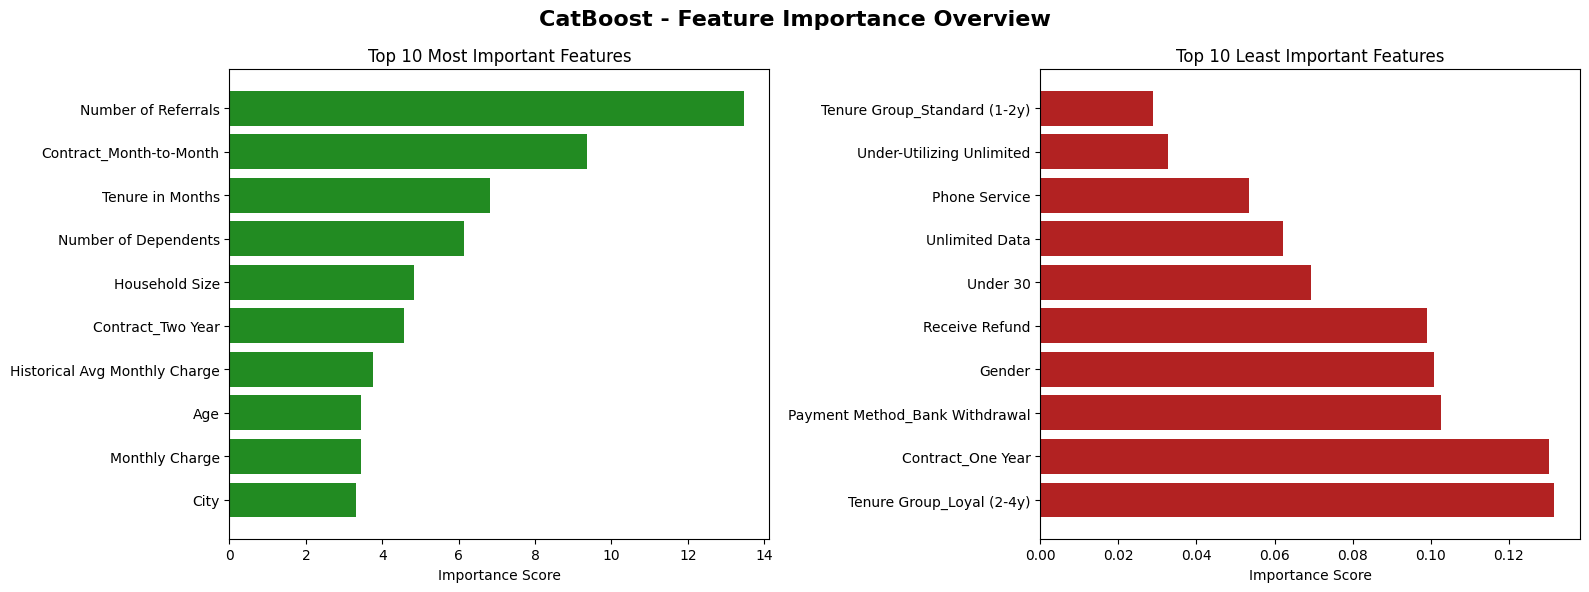

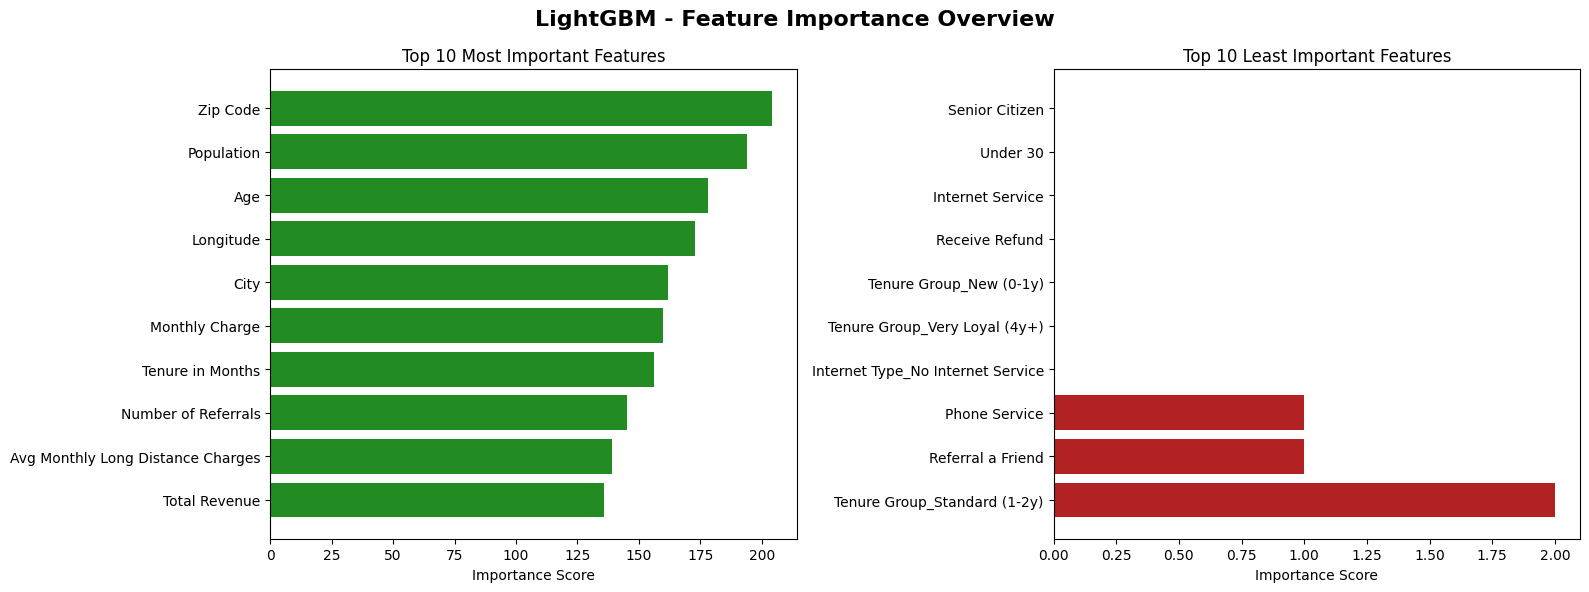

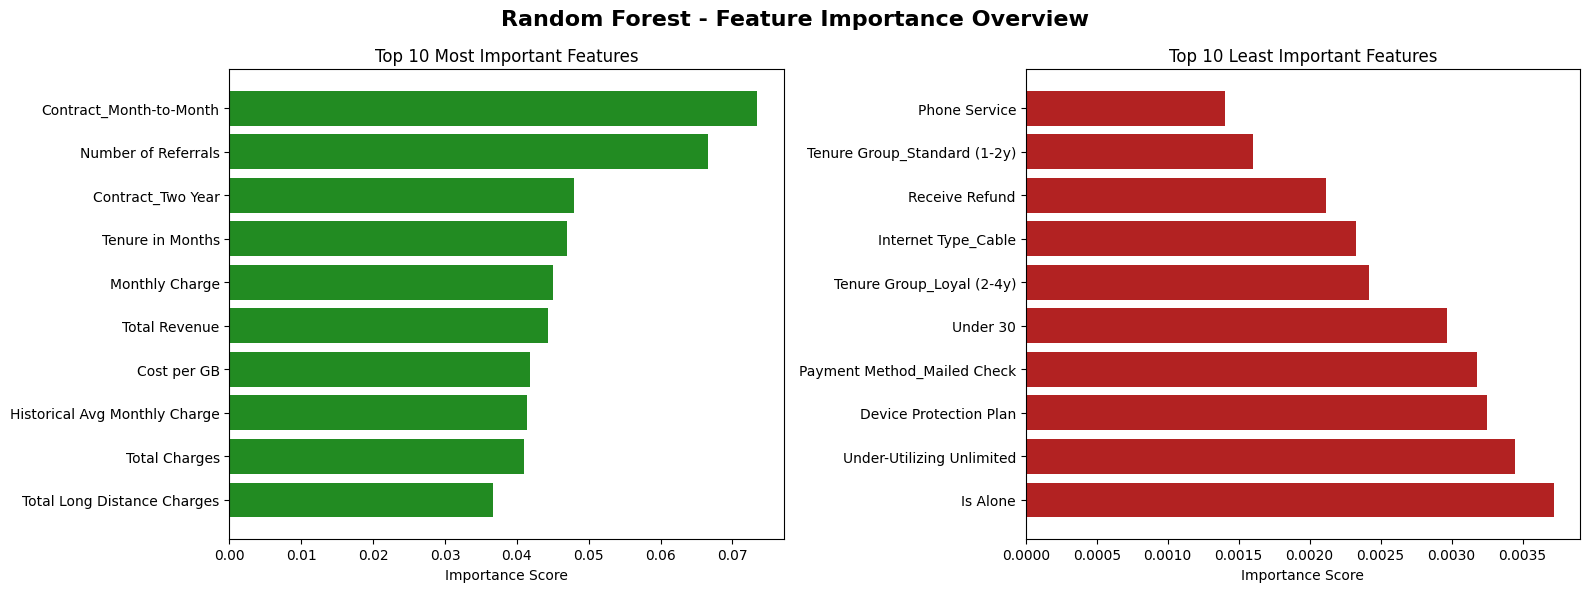

In [12]:
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
lgb = LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
cb = CatBoostClassifier(auto_class_weights='Balanced', thread_count=-1, task_type='GPU', random_state=42, verbose=False)

models = {
    'CatBoost': cb,
    'LightGBM': lgb,
    'Random Forest': rf
}

for name, model in models.items():
    model.fit(X_train, y_train)
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=True)

    most = importance_df.tail(10)
    least = importance_df.head(10)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(most['Feature'], most['Importance'], color='forestgreen')
    axes[0].set_title('Top 10 Most Important Features')
    axes[0].set_xlabel('Importance Score')

    axes[1].barh(least['Feature'][::-1], least['Importance'][::-1], color='firebrick')
    axes[1].set_title('Top 10 Least Important Features')
    axes[1].set_xlabel('Importance Score')
    plt.suptitle(f'{name} - Feature Importance Overview', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [13]:
X_train_reduced = {}
X_val_reduced = {}
X_test_reduced = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    least = importances.sort_values(ascending=True).head(15).index.tolist()

    X_train_reduced[name] = X_train.drop(columns=least)
    X_val_reduced[name] = X_val.drop(columns=least)
    X_test_reduced[name] = X_test.drop(columns=least)

    print(f"--- {name} ---")
    print(f"Dropped: {least}\n")

--- CatBoost ---
Dropped: ['Tenure Group_Standard (1-2y)', 'Under-Utilizing Unlimited', 'Phone Service', 'Unlimited Data', 'Under 30', 'Receive Refund', 'Gender', 'Payment Method_Bank Withdrawal', 'Contract_One Year', 'Tenure Group_Loyal (2-4y)', 'Bill Shock', 'Internet Type_Cable', '30 to 64', 'Device Protection Plan', 'Tenure Group_Very Loyal (4y+)']

--- LightGBM ---
Dropped: ['Senior Citizen', 'Under 30', 'Internet Service', 'Receive Refund', 'Tenure Group_New (0-1y)', 'Tenure Group_Very Loyal (4y+)', 'Internet Type_No Internet Service', 'Phone Service', 'Referral a Friend', 'Tenure Group_Standard (1-2y)', 'Tenure Group_Loyal (2-4y)', 'Is Alone', 'Under-Utilizing Unlimited', 'Unlimited Data', '30 to 64']

--- Random Forest ---
Dropped: ['Phone Service', 'Tenure Group_Standard (1-2y)', 'Receive Refund', 'Internet Type_Cable', 'Tenure Group_Loyal (2-4y)', 'Under 30', 'Payment Method_Mailed Check', 'Device Protection Plan', 'Under-Utilizing Unlimited', 'Is Alone', 'Unlimited Data', 'T

In [14]:
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
lgb = LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
cb = CatBoostClassifier(auto_class_weights='Balanced', thread_count=-1, task_type='GPU', random_state=42, verbose=False)

models = {
    'CatBoost': cb,
    'LightGBM': lgb,
    'Random Forest': rf
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

reduced_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train_reduced[name], y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)

    reduced_results.append({
        'Model': name,
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision']),
        'Recall': np.mean(scores['test_recall']),
        'F1': np.mean(scores['test_f1']),
        'AUC': np.mean(scores['test_roc_auc'])
    })

pd.DataFrame(reduced_results).sort_values(by='F1', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,AUC
0,CatBoost,0.837324,0.662235,0.792813,0.721341,0.909514
1,LightGBM,0.840165,0.679427,0.754587,0.714907,0.904574
2,Random Forest,0.838541,0.748782,0.590214,0.659846,0.890434


# 5. Hyperparameter Tuning

In [17]:
def objective_cb(trial):
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }

    model = CatBoostClassifier(**param, auto_class_weights='Balanced', iterations=5000, thread_count=-1, task_type='GPU', random_state=42, verbose=False)

    model.fit(
        X_train_reduced['CatBoost'], y_train,
        eval_set=[(X_val_reduced['CatBoost'], y_val)],
        early_stopping_rounds=50,
        verbose=False
    )

    trial.set_user_attr("best_iterations", model.get_best_iteration())

    y_pred = model.predict(X_val_reduced['CatBoost'])
    return recall_score(y_val, y_pred)

def objective_lgb(trial):
    param = {
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
      'max_depth': trial.suggest_int('max_depth', 3, 9),
      'num_leaves': trial.suggest_int('num_leaves', 10, 100),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
      'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
    }

    model = LGBMClassifier(**param, class_weight='balanced', n_estimators=5000, n_jobs=-1, random_state=42, verbose=-1)

    model.fit(
        X_train_reduced['LightGBM'], y_train,
        eval_set=[(X_val_reduced['LightGBM'], y_val)],
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
    )

    trial.set_user_attr("best_n_estimators", model.best_iteration_)

    y_pred = model.predict(X_val_reduced['LightGBM'])
    return recall_score(y_val, y_pred)

def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = RandomForestClassifier(**param, class_weight='balanced', n_jobs=-1, random_state=42)

    model.fit(X_train_reduced['Random Forest'], y_train)

    y_pred = model.predict(X_val_reduced['Random Forest'])
    return recall_score(y_val, y_pred)

In [18]:
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=50)

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=50)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

[I 2026-07-28 05:48:26,966] A new study created in memory with name: no-name-dde492ed-2e08-420d-81d9-0fe8ce731ce5
[I 2026-07-28 05:48:46,162] Trial 0 finished with value: 0.8285714285714286 and parameters: {'learning_rate': 0.010686823239412, 'depth': 6, 'l2_leaf_reg': 5.936922710037839, 'random_strength': 0.21920553439673116, 'bagging_temperature': 0.030661730210131632}. Best is trial 0 with value: 0.8285714285714286.
[I 2026-07-28 05:49:00,964] Trial 1 finished with value: 0.8392857142857143 and parameters: {'learning_rate': 0.10941165750985034, 'depth': 10, 'l2_leaf_reg': 2.482380676645327, 'random_strength': 2.7724035377475578, 'bagging_temperature': 0.16921639393384924}. Best is trial 1 with value: 0.8392857142857143.
[I 2026-07-28 05:50:14,016] Trial 2 finished with value: 0.8285714285714286 and parameters: {'learning_rate': 0.017841852550654264, 'depth': 10, 'l2_leaf_reg': 5.04262511894199, 'random_strength': 0.2096165400791914, 'bagging_temperature': 0.5823652076861315}. Best i

In [23]:
cb_best_params = study_cb.best_params
cb_best_params['iterations'] = study_cb.best_trial.user_attrs['best_iterations']

lgb_best_params = study_lgb.best_params
lgb_best_params['n_estimators'] = study_lgb.best_trial.user_attrs['best_n_estimators']

rf_best_params = study_rf.best_params

cb_tuned = CatBoostClassifier(**cb_best_params, auto_class_weights='Balanced', thread_count=-1, task_type='GPU', random_state=42, verbose=False)
lgb_tuned = LGBMClassifier(**lgb_best_params, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)
rf_tuned = RandomForestClassifier(**rf_best_params, class_weight='balanced', n_jobs=-1, random_state=42)

tuned_models = {
    'CatBoost': cb_tuned,
    'LightGBM': lgb_tuned,
    'Random Forest': rf_tuned
}

In [25]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = []

for name, model in tuned_models.items():
    scores = cross_validate(model, X_train_reduced[name], y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1)

    cv_results.append({
        'Model': name,
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision']),
        'Recall': np.mean(scores['test_recall']),
        'F1': np.mean(scores['test_f1']),
        'AUC': np.mean(scores['test_roc_auc'])
    })

pd.DataFrame(cv_results).sort_values(by='Recall', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.777893,0.553080,0.855505,0.671702,0.878974
1,CatBoost,0.818257,0.615073,0.844037,0.711440,0.911754
2,LightGBM,0.821502,0.622129,0.834098,0.712632,0.908940


--- CatBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       776
           1       0.63      0.86      0.73       281

    accuracy                           0.83      1057
   macro avg       0.79      0.84      0.80      1057
weighted avg       0.86      0.83      0.84      1057



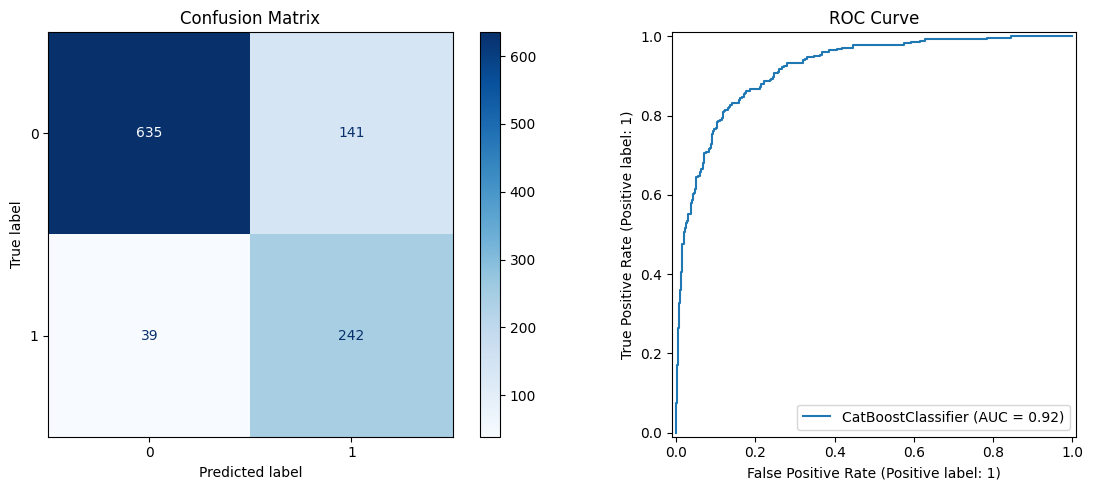

--- LightGBM Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       776
           1       0.63      0.85      0.73       281

    accuracy                           0.83      1057
   macro avg       0.79      0.84      0.80      1057
weighted avg       0.86      0.83      0.84      1057



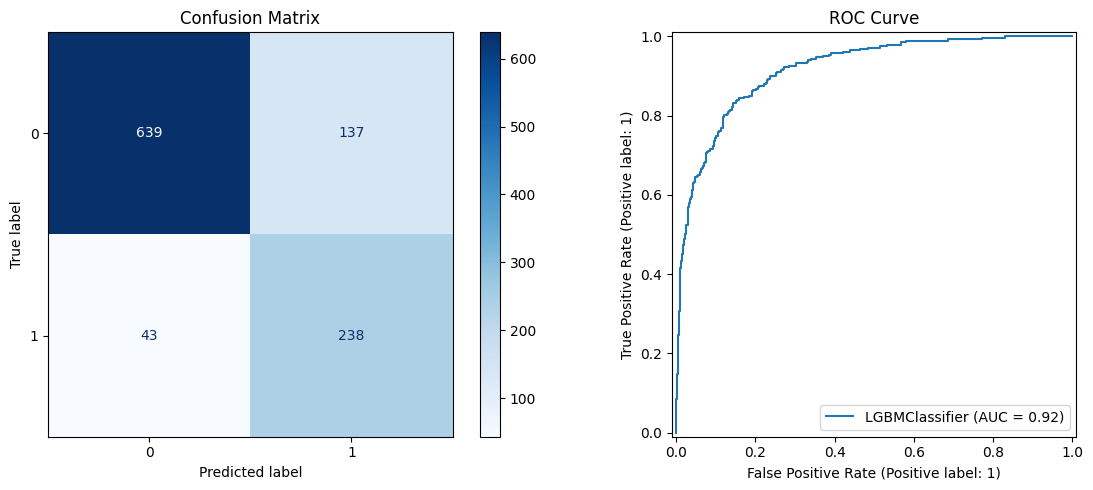

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       776
           1       0.56      0.89      0.69       281

    accuracy                           0.79      1057
   macro avg       0.75      0.82      0.76      1057
weighted avg       0.84      0.79      0.80      1057



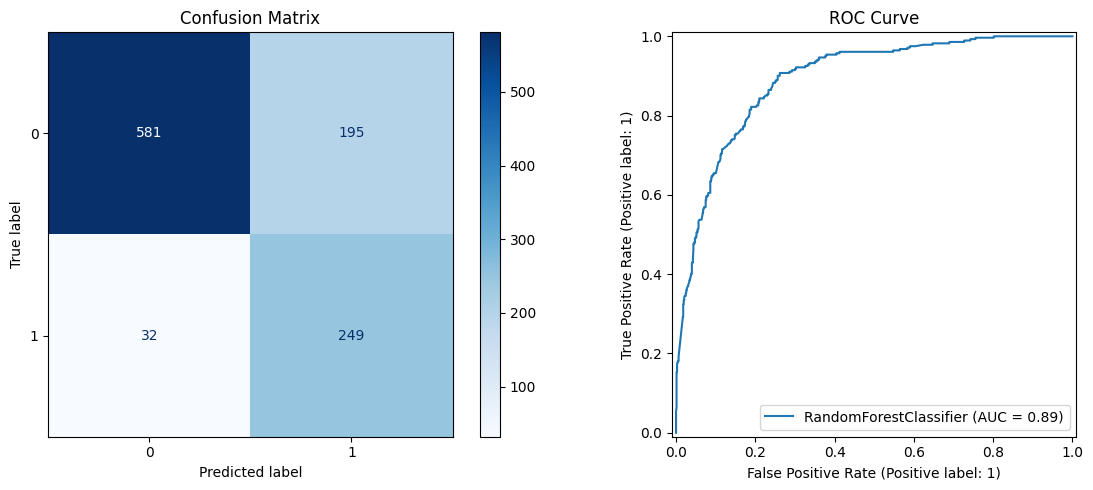

In [26]:
for name, model in tuned_models.items():
    model.fit(X_train_reduced[name], y_train)
    y_pred = model.predict(X_test_reduced[name])

    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_estimator(model, X_test_reduced[name], y_test, cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_estimator(model, X_test_reduced[name], y_test, ax=axes[1])
    axes[1].set_title("ROC Curve")

    plt.tight_layout()
    plt.show()

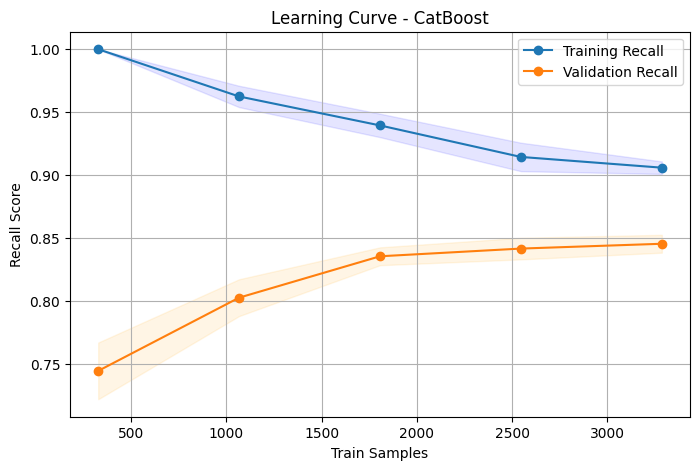

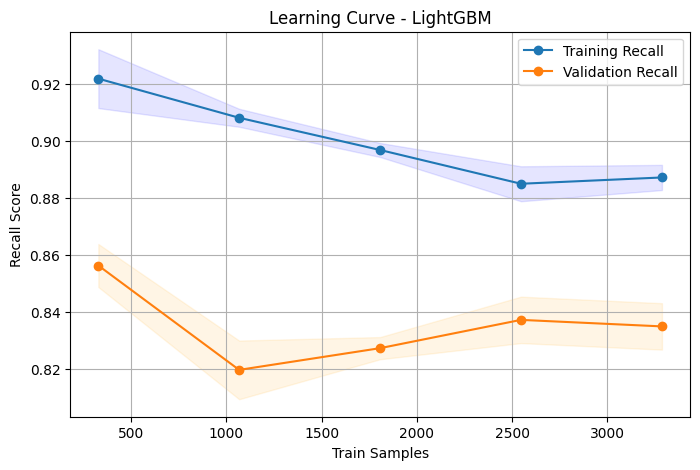

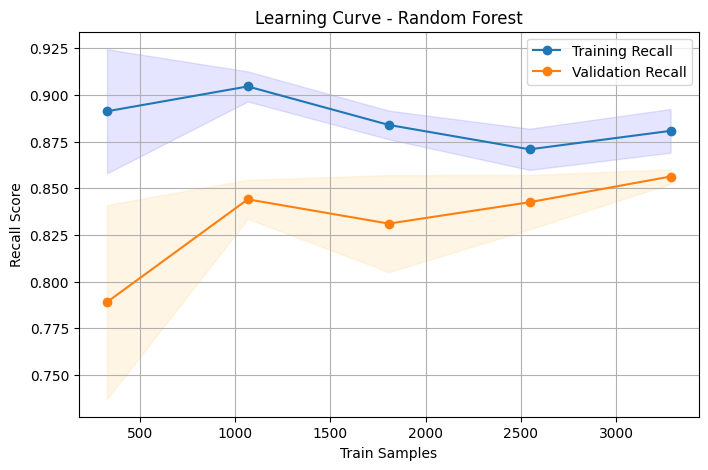

In [27]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in tuned_models.items():
    plt.figure(figsize=(8, 5))

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_reduced[name], y_train, cv=cv, scoring='recall'
    )

    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Recall')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation Recall')

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="orange")

    plt.legend()
    plt.xlabel('Train Samples')
    plt.ylabel('Recall Score')
    plt.title(f'Learning Curve - {name}')
    plt.grid()
    plt.show()

# 6. Final Evaluation

In [29]:
final_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_reduced[name])
    y_pred_proba = model.predict_proba(X_test_reduced[name])[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    final_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': roc_auc
    })

results_df = pd.DataFrame(final_results).sort_values(by='Recall', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.785241,0.560811,0.886121,0.686897,0.891952
1,CatBoost,0.829707,0.631854,0.861210,0.728916,0.920167
2,LightGBM,0.829707,0.634667,0.846975,0.725610,0.917283


# 7. Export Models

In [30]:
joblib.dump(cb_tuned, '/content/drive/MyDrive/churn/CatBoost Model.pkl')
joblib.dump(lgb_tuned, '/content/drive/MyDrive/churn/LightGBM Model.pkl')
joblib.dump(rf_tuned, '/content/drive/MyDrive/churn/Random Forest Model.pkl')

['/content/drive/MyDrive/churn/Random Forest Model.pkl']